In [1]:
import torch
from model.builder import load_pretrained_model
from util.mm_utils import tokenizer_image_token
from PIL import Image
from conversation import conv_templates
from util.mm_utils import tokenizer_image_token
from constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
import json
import os
from util.data_aug import crop, random_rotate

/research/chengruogu/anaconda3/envs/bunny/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def expand2square(pil_img, background_color):
    width, height = pil_img.size
    if width == height:
        return pil_img
    elif width > height:
        result = Image.new(pil_img.mode, (width, width), background_color)
        result.paste(pil_img, (0, (width - height) // 2))
        return result
    else:
        result = Image.new(pil_img.mode, (height, height), background_color)
        result.paste(pil_img, ((height - width) // 2, 0))
        return result

In [3]:
# set device
torch.set_default_device('cuda:0')  # or 'cuda'
# torch.cuda.set_device(0) 
tokenizer, model, image_processor, context_len = load_pretrained_model(model_path='/research/zhangzr/Bunny/checkpoints/checkpoints-yi1.5/bunny-lora-yi1.5-9B-Chat-qa-FormalGeoV2Aug10Times_structure_only-sft2-old/merged', 
                                                                       vision_encoder_path='/research/zhangzr/Bunny/checkpoints/checkpoints-yi1.5/bunny-lora-yi1.5-9B-Chat-qa-FormalGeoV2Aug10Times_structure_only-sft2-old/merged', 
                                                                       model_base=None, 
                                                                       model_name='bunny-yi',
                                                                       model_type='yi1.5',
                                                                       device_map=None,
                                                                       device='cuda:0')

Loading checkpoint shards: 100%|██████████| 4/4 [00:09<00:00,  2.48s/it]
Some weights of the model checkpoint at /research/zhangzr/Bunny/checkpoints/checkpoints-yi1.5/bunny-lora-yi1.5-9B-Chat-qa-FormalGeoV2Aug10Times_structure_only-sft2-old/merged were not used when initializing BunnyLlamaForCausalLM: ['model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding.bias', 'model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding.weight', 'model.vision_tower.vision_tower.vision_model.embeddings.position_embedding.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm2.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm2.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.mlp.fc1.bias', 'model.vision_tower.vision_tower.vision

loading siglip from google/siglip-so400m-patch14-384
loading vision tower from ['/research/zhangzr/Bunny/checkpoints/checkpoints-yi1.5/bunny-lora-yi1.5-9B-Chat-qa-FormalGeoV2Aug10Times_structure_only-sft2-old/merged/model-00003-of-00004.safetensors', '/research/zhangzr/Bunny/checkpoints/checkpoints-yi1.5/bunny-lora-yi1.5-9B-Chat-qa-FormalGeoV2Aug10Times_structure_only-sft2-old/merged/model-00002-of-00004.safetensors', '/research/zhangzr/Bunny/checkpoints/checkpoints-yi1.5/bunny-lora-yi1.5-9B-Chat-qa-FormalGeoV2Aug10Times_structure_only-sft2-old/merged/model-00004-of-00004.safetensors', '/research/zhangzr/Bunny/checkpoints/checkpoints-yi1.5/bunny-lora-yi1.5-9B-Chat-qa-FormalGeoV2Aug10Times_structure_only-sft2-old/merged/model-00001-of-00004.safetensors']


In [4]:
with open('/research/zhangzr/Bunny/data/formalgeo7k/formalgeo7k_v2/custom_json/qa_structure_only/qa_structure_only_train_aug.json', 'r') as f:
    data = json.load(f)

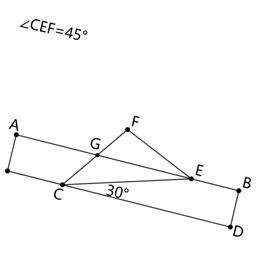

Prompt is:
<|im_start|>user
<image>
Based on the image, predict the image_cdl.<|im_end|>
<|im_start|>assistant


GT is:
image_cdl:
Equal(MeasureOfAngle(ECD),30),Equal(MeasureOfAngle(CEF),45)


In [7]:
# set up conversation templates
conv_mode = 'yi-chat'
conv = conv_templates[conv_mode].copy()
idx = len(data)-780

root_path = '/research/zhangzr/Bunny/data/formalgeo7k/formalgeo7k_v2'
image_path = os.path.join(root_path, data[idx]['image'])
# image_path = '/research/zhangzr/Bunny/data/caption_data_syth_v35/test/img_30.png'
qs = data[idx]['conversations'][0]['value']
# qs = '<image>\nBased on the image, first describe what you see in the figure, then predict the construction_cdl and image_cdl.'
# qs = '<image>\nDescribe what you see in the figure.'
# qs = '<image>\n解析这幅图像。'
# qs = 'Recount the details depicted in the figure.'
ans = data[idx]['conversations'][1]['value']




# text prompt
# problem_text_en = 'As shown in the diagram, KL=NL, NM=ML, \u2220JLK=25\u00b0, \u2220KLN=18\u00b0, \u2220NKJ=130\u00b0, \u2220NLM=20\u00b0. Find the measure of \u2220MNL.'
# qs = f'Based on the image, predict the construction_cdl. Then, based on the problem_text, predict the text_cdl and image_cdl, and parse out the goal_cdl.\nProblem_text is: {problem_text_en}'
# text_qs = "As shown in the diagram, \u2220ACB=70\u00b0, the center of \u2299O is O. Find the measure of \u2220BAO."
# qs = f'Based on the image, first predict the construction_cdl. Then, based on the problem_text, predict the text_cdl and image_cdl, and parse out the goal_cdl. Finally, provide the predicted theorem_seqs and the problem answer.\nProblem_text is: {text_qs}'
# qs = DEFAULT_IMAGE_TOKEN + '\n '+ qs
# qs = '帮我想想今天吃什么'
conv.append_message(conv.roles[0], qs)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()


input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).to('cuda')
#image = Image.open('data/images/geoqa_plus/49.png').convert('RGB')
image = Image.open(image_path).convert('RGB')
image = crop(random_rotate(image))
if model.config.image_aspect_ratio == 'pad':
    # print('using pad')
    image = expand2square(image, (255, 255, 255))
       
image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'][0]
image_tensor = image_tensor.unsqueeze(0).to(dtype=model.dtype, device='cuda:0', non_blocking=True).to('cuda')

image.resize((256, 256)).show()
print(f'Prompt is:\n{prompt}\n')
print(f'GT is:\n{ans}')
# print(f'Input ID is\n{input_ids}')

In [8]:
# generate
with torch.inference_mode():
    output_ids = model.generate(
        input_ids,
        images=image_tensor,
        do_sample=False,
        top_p=None,
        top_k=None,
        temperature=None,
        num_beams=1,
        max_new_tokens=1024,
        repetition_penalty=None,
        use_cache=True)[0]
# print(f'output id is{output_ids}')
res = tokenizer.decode(output_ids[input_ids.shape[1]:], skip_special_tokens=True).strip()
print(f'Respones is:\n{res}')
# image.resize((128, 128)).show()

Respones is:
As shown in the diagram, ∠CEF=45°, ∠ECD=30°, AHDB is a rectangle, EF and FC are the legs of the right triangle EFC.


### Multi Turn Conversation

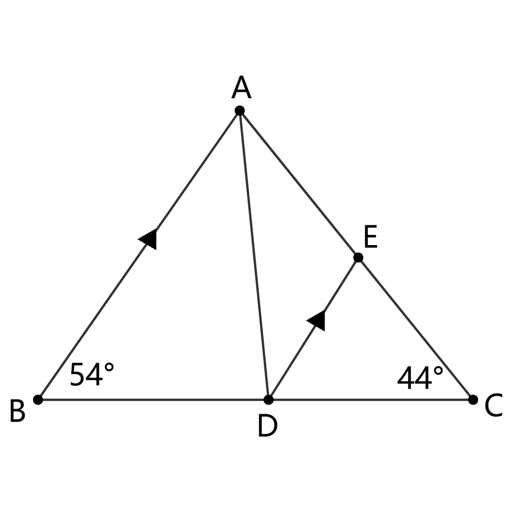

Respones is:
construction_cdl:
Shape(AB,BD,DA),Shape(AD,DE,EA),Shape(ED,DC,CE),Collinear(BDC),Collinear(AEC)
image_cdl:
Equal(MeasureOfAngle(ABC),54),Equal(MeasureOfAngle(DCE),44),ParallelBetweenLine(BA,DE)
Respones is:
text_cdl:
Equal(MeasureOfAngle(ABD),44),Equal(MeasureOfAngle(DCE),54),IsBisectorOfAngle(AD,CAB),ParallelBetweenLine(ED,AB)
goal_cdl:
['Value(MeasureOfAngle(ADE))']
Respones is:
theorem_seqs:
parallel_property_corresponding_angle(2,BA,DE,C),angle_addition(1,CAE,EAB),angle_addition(1,DEA,AEC),triangle_property_angle_sum(1,CAB),adjacent_complementary_angle(1,ADE,EDC)
answer:
40


In [15]:
idx = 3182
image_path = f'/research/zhangzr/Bunny/data/formalgeo7k/formalgeo7k_v2/diagrams/{idx}.png'
image = Image.open(image_path).convert('RGB')
image = crop(image)
if model.config.image_aspect_ratio == 'pad':
    # print('using pad')
    image = expand2square(image, (255, 255, 255))
image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'][0]
image_tensor = image_tensor.unsqueeze(0).to(dtype=model.dtype, device='cuda:4', non_blocking=True)
image.resize((512, 512)).show()

conv_mode = 'qwen-chat'
conv = conv_templates[conv_mode].copy()
with open(f'/research/zhangzr/Bunny/data/formalgeo7k/formalgeo7k_v2/problems/{idx}.json', 'r') as f:
    info = json.load(f)
problem_text_en = info['problem_text_en']
qs_lst = ["<image>\nBased on the image, predict the construction_cdl and image_cdl.", 
          f"Then, based on the problem_text, predict the text_cdl, and parse out the goal_cdl.\nProblem_text: {problem_text_en}",
          "Finally, provide the predicted theorem_seqs and the problem answer."]

for qs in qs_lst:
    conv.append_message(conv.roles[0], qs)
    conv.append_message(conv.roles[1], None)
    prompt = conv.get_prompt()
    # print(f'Prompt is\n{prompt}')
    input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).to('cuda:4')

    # generate
    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            do_sample=False,
            top_p=None,
            top_k=None,
            temperature=None,
            num_beams=1,
            max_new_tokens=1024,
            repetition_penalty=None,
            use_cache=False)[0]
    # print(f'output id is{output_ids}')
    res = tokenizer.decode(output_ids[input_ids.shape[1]:], skip_special_tokens=True).strip()
    conv.messages[-1] = [conv.roles[1], res]
    print(f'Respones is:\n{res}')


In [16]:
print(info)

{'problem_id': 3182, 'annotation': 'JiaZou_2023-04-23', 'annotation_img': 'YanjunGuo_2024-01-29', 'source': 'GeoQA-464', 'problem_text_cn': '如图所示，∠ABD=44°，∠DCE=54°，AD平分∠CAB，ED平行于AB。求∠ADE的大小。', 'problem_text_en': 'As shown in the diagram, ∠ABD=44°, ∠DCE=54°, AD bisects ∠CAB, ED∥AB. Find the measure of ∠ADE.', 'problem_img': '3182.png', 'construction_cdl': ['Shape(AB,BD,DA)', 'Shape(AD,DE,EA)', 'Shape(ED,DC,CE)', 'Collinear(BDC)', 'Collinear(AEC)'], 'text_cdl': ['Equal(MeasureOfAngle(ABD),44)', 'Equal(MeasureOfAngle(DCE),54)', 'IsBisectorOfAngle(AD,CAB)', 'ParallelBetweenLine(ED,AB)'], 'image_cdl': ['Equal(MeasureOfAngle(ABD),44)', 'Equal(MeasureOfAngle(DCE),54)', 'ParallelBetweenLine(ED,AB)'], 'goal_cdl': 'Value(MeasureOfAngle(ADE))', 'problem_answer': '41', 'theorem_seqs': ['triangle_property_angle_sum(1,ABC)', 'angle_addition(1,EAD,DAB)', 'parallel_property_alternate_interior_angle(2,BA,DE)'], 'theorem_seqs_dag': {'START': ['triangle_property_angle_sum(1,ABC)', 'angle_addition(1,EAD,D